,Label,brand,name,price,rank,ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


              Label     brand
count          1472      1472
unique            6       116
top     Moisturizer  CLINIQUE
freq            298        79


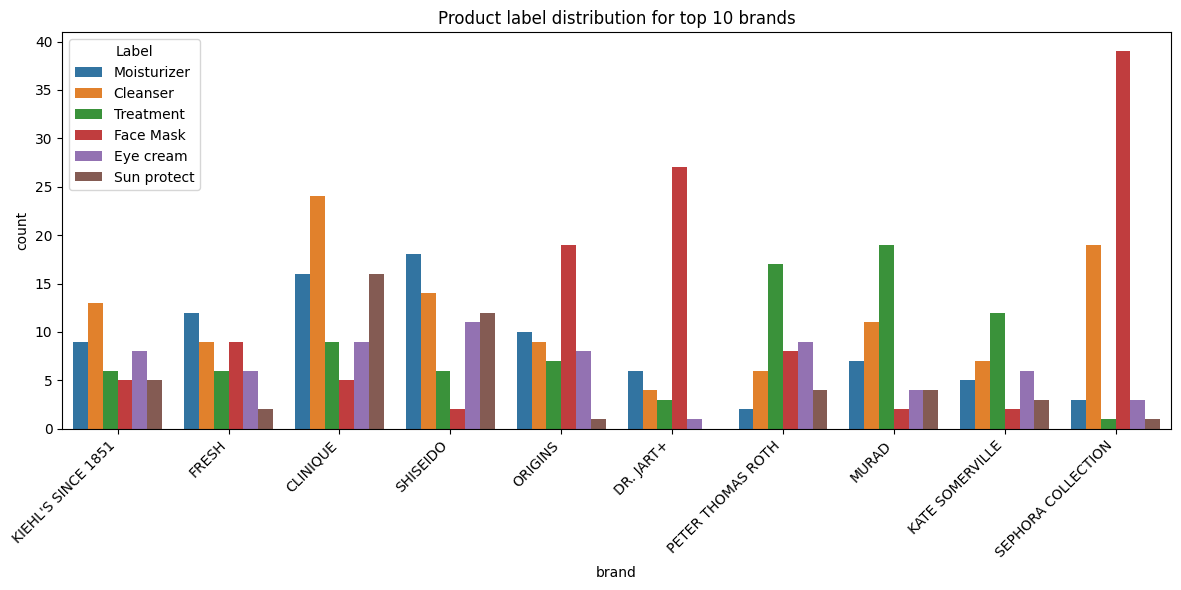

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
csv_path = "../data/cosmetic_p.csv"
df = pd.read_csv(csv_path)

# Basic info
display(df.head())
print(df[["Label", "brand"]].describe(include="all"))

# Simple visualization: distribution of labels across top brands
plt.figure(figsize=(12, 6))
top_brands = df["brand"].value_counts().head(10).index
subset = df[df["brand"].isin(top_brands)]
sns.countplot(data=subset, x="brand", hue="Label")
plt.xticks(rotation=45, ha="right")
plt.title("Product label distribution for top 10 brands")
plt.tight_layout()
plt.show()


In [5]:
# Dataset overview
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumber of unique values per column:")
print(df.nunique())

Shape (rows, columns): (1472, 11)

Column names: ['Label', 'brand', 'name', 'price', 'rank', 'ingredients', 'Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']

Data types:
Label              str
brand              str
name               str
price            int64
rank           float64
ingredients        str
Combination      int64
Dry              int64
Normal           int64
Oily             int64
Sensitive        int64
dtype: object

Missing values per column:
Label          0
brand          0
name           0
price          0
rank           0
ingredients    0
Combination    0
Dry            0
Normal         0
Oily           0
Sensitive      0
dtype: int64

Number of unique values per column:
Label             6
brand           116
name           1472
price           146
rank             29
ingredients    1337
Combination       2
Dry               2
Normal            2
Oily              2
Sensitive         2
dtype: int64


In [6]:
# Categorical summaries for Label and brand
print("Unique labels:", df["Label"].unique())
print("\nLabel value counts:")
print(df["Label"].value_counts())

print("\nNumber of unique brands:", df["brand"].nunique())
print("Top 20 brands by count:\n", df["brand"].value_counts().head(20))

Unique labels: <StringArray>
['Moisturizer', 'Cleanser', 'Treatment', 'Face Mask', 'Eye cream',
 'Sun protect']
Length: 6, dtype: str

Label value counts:
Label
Moisturizer    298
Cleanser       281
Face Mask      266
Treatment      248
Eye cream      209
Sun protect    170
Name: count, dtype: int64

Number of unique brands: 116
Top 20 brands by count:
 brand
CLINIQUE              79
SEPHORA COLLECTION    66
SHISEIDO              63
ORIGINS               54
MURAD                 47
KIEHL'S SINCE 1851    46
PETER THOMAS ROTH     46
FRESH                 44
DR. JART+             41
KATE SOMERVILLE       35
LANCÔME               34
ESTÉE LAUDER          32
LA MER                30
CAUDALIE              30
PERRICONE MD          30
PHILOSOPHY            29
FIRST AID BEAUTY      28
OLEHENRIKSEN          27
ALGENIST              27
DIOR                  27
Name: count, dtype: int64


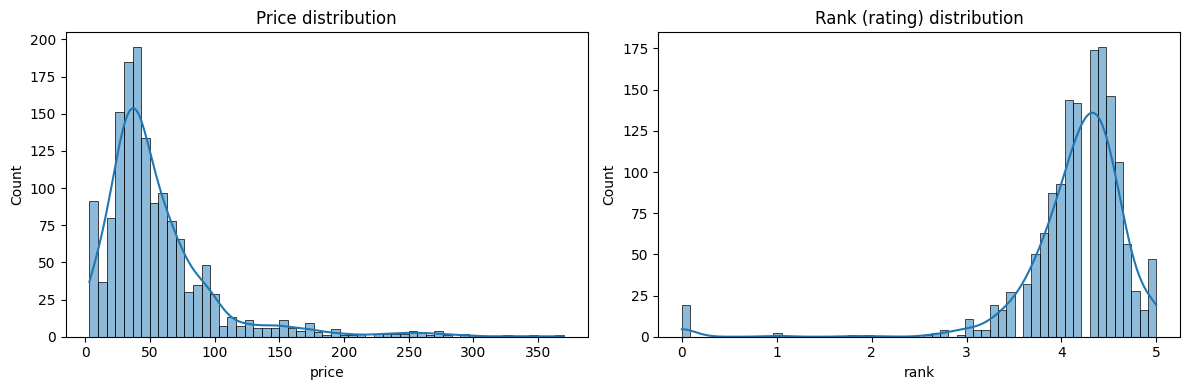

In [7]:
# Numerical distributions: price and rank
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["price"], kde=True, ax=axes[0])
axes[0].set_title("Price distribution")

sns.histplot(df["rank"], kde=True, ax=axes[1])
axes[1].set_title("Rank (rating) distribution")

plt.tight_layout()
plt.show()

Skin-type suitability counts across products:
 Combination    966
Normal         960
Dry            904
Oily           894
Sensitive      756
dtype: int64


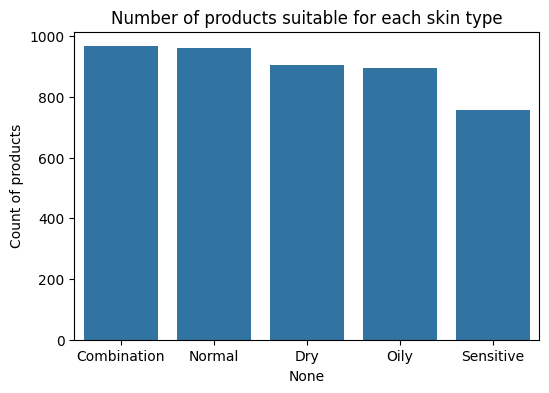

In [8]:
# Skin type suitability counts
skin_cols = ["Combination", "Dry", "Normal", "Oily", "Sensitive"]

skin_counts = df[skin_cols].sum().sort_values(ascending=False)
print("Skin-type suitability counts across products:\n", skin_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=skin_counts.index, y=skin_counts.values)
plt.title("Number of products suitable for each skin type")
plt.ylabel("Count of products")
plt.show()

count    1472.000000
mean      701.610054
std       533.033326
min         7.000000
25%       374.500000
50%       649.500000
75%       933.250000
max      5535.000000
Name: ingredient_length, dtype: float64


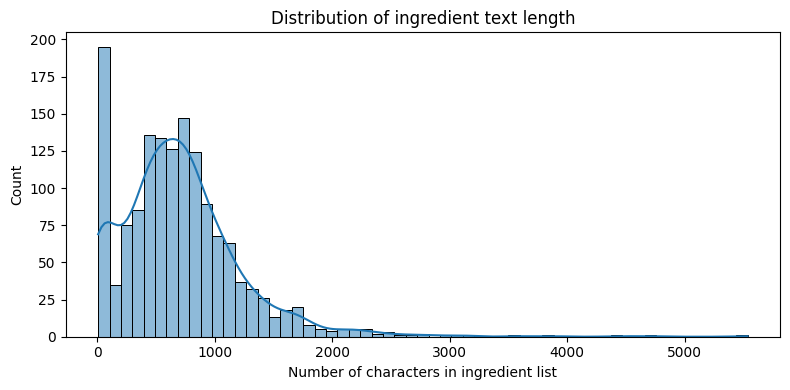

In [9]:
# Text feature: ingredient length

df["ingredient_length"] = df["ingredients"].astype(str).str.len()

print(df["ingredient_length"].describe())

plt.figure(figsize=(8,4))
sns.histplot(df["ingredient_length"], kde=True)
plt.title("Distribution of ingredient text length")
plt.xlabel("Number of characters in ingredient list")
plt.tight_layout()
plt.show()

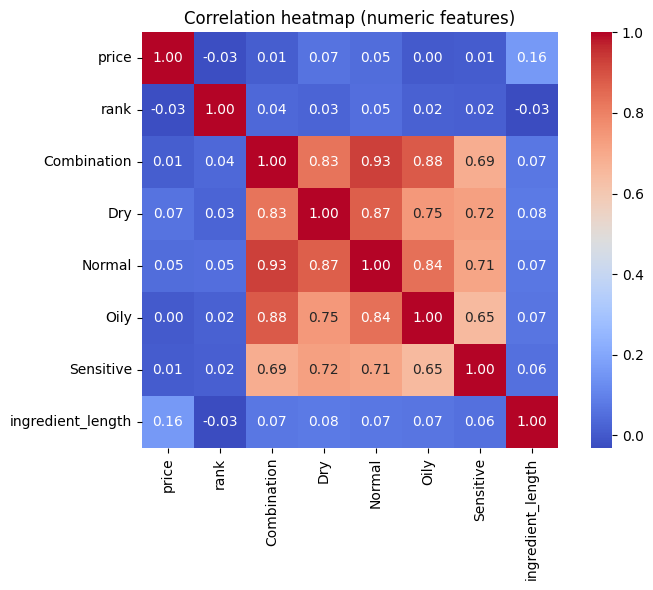

In [10]:
# Correlation matrix for numeric features

numeric_cols = df.select_dtypes(include=["number"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

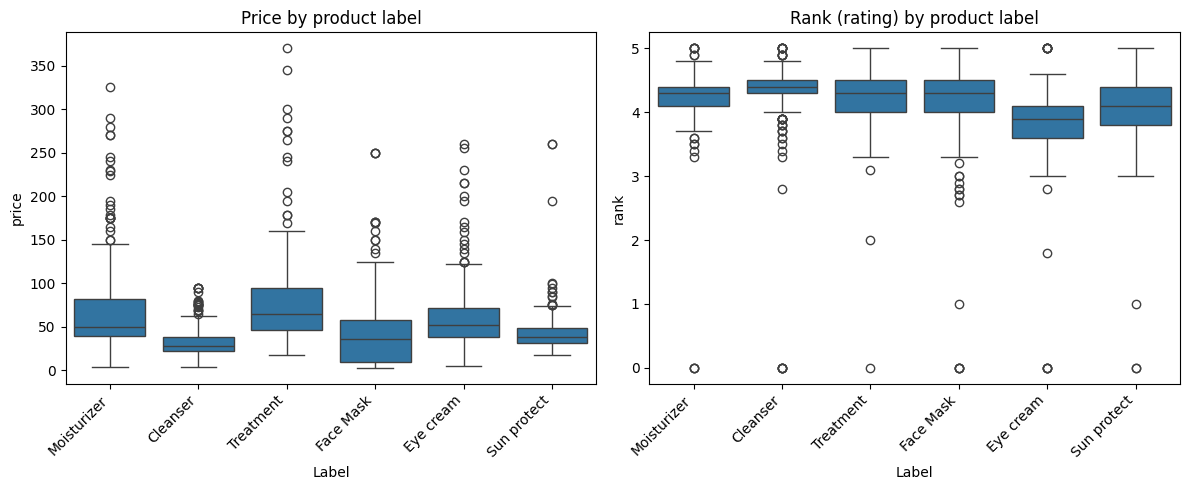

In [11]:
# Price and rank by label

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="Label", y="price")
plt.xticks(rotation=45, ha="right")
plt.title("Price by product label")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="Label", y="rank")
plt.xticks(rotation=45, ha="right")
plt.title("Rank (rating) by product label")

plt.tight_layout()
plt.show()

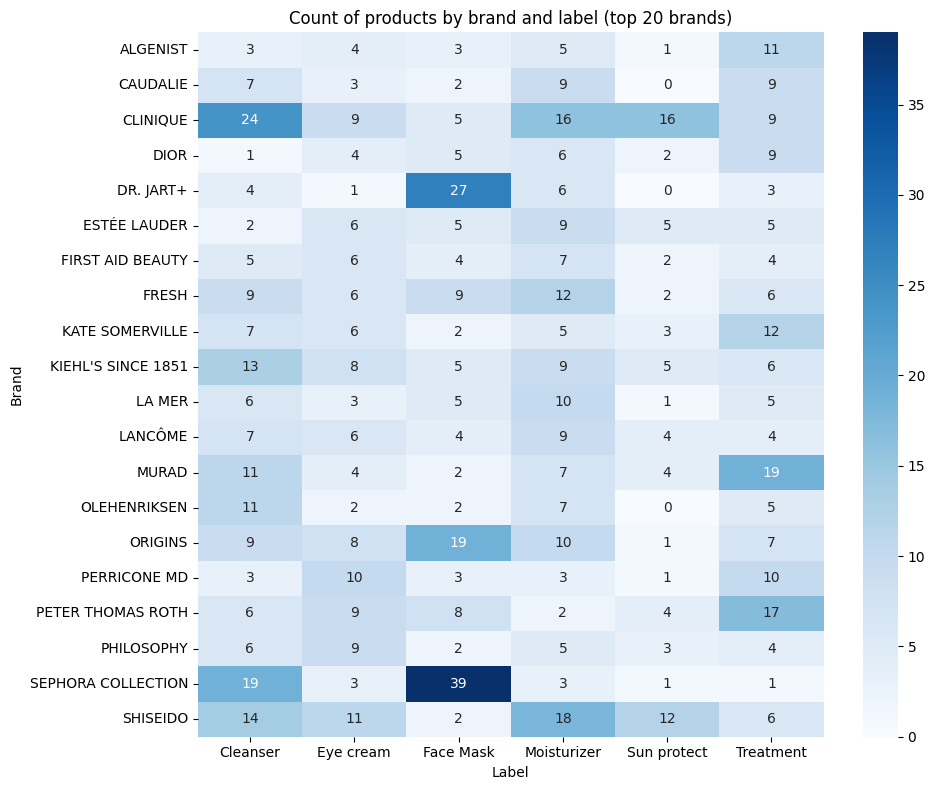

In [12]:
# Brand vs label pivot heatmap (top brands)

# Focus on top 20 brands
top_brands_20 = df["brand"].value_counts().head(20).index
sub = df[df["brand"].isin(top_brands_20)]

pivot = sub.pivot_table(index="brand", columns="Label", values="name", aggfunc="count", fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Count of products by brand and label (top 20 brands)")
plt.ylabel("Brand")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

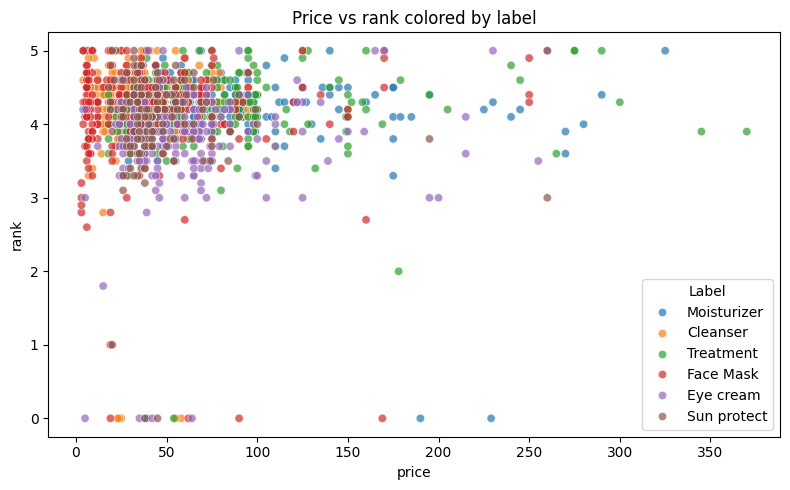

In [13]:
# Relationship between price and rank, colored by label

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="price", y="rank", hue="Label", alpha=0.7)
plt.title("Price vs rank colored by label")
plt.tight_layout()
plt.show()

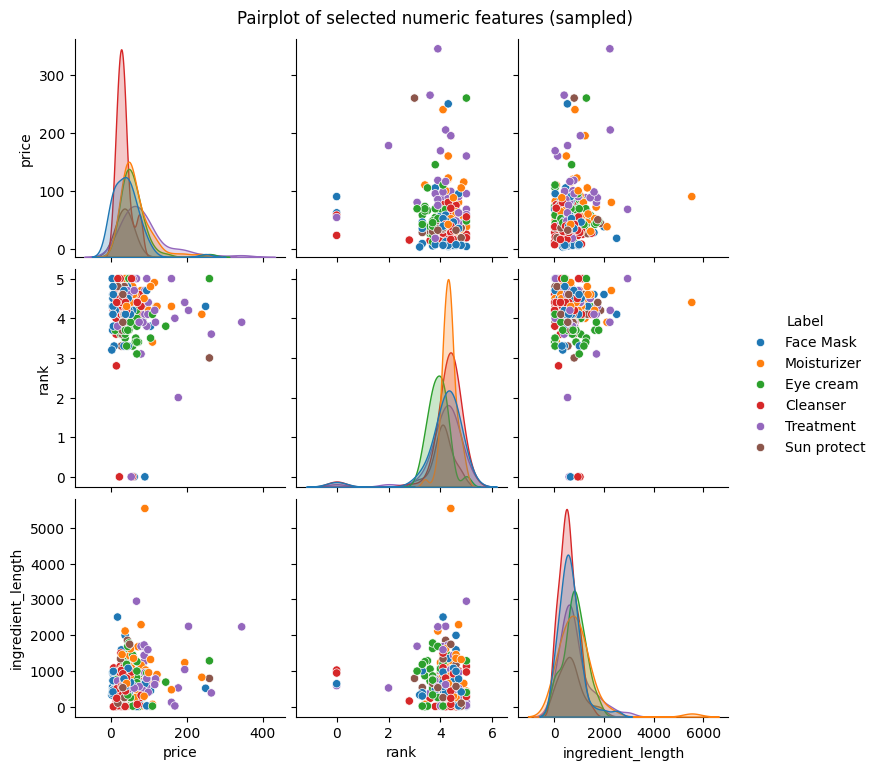

In [14]:
# Optional: pairplot on a small sample (can be slow on full data)

sample = df.sample(n=min(300, len(df)), random_state=42)
sns.pairplot(sample, vars=["price", "rank", "ingredient_length"], hue="Label")
plt.suptitle("Pairplot of selected numeric features (sampled)", y=1.02)
plt.show()